In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [3]:
mnist = keras.datasets.mnist
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()


In [4]:
x_train_full.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
x_train_full[1] # show the first cell/ raw pixel values of one image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

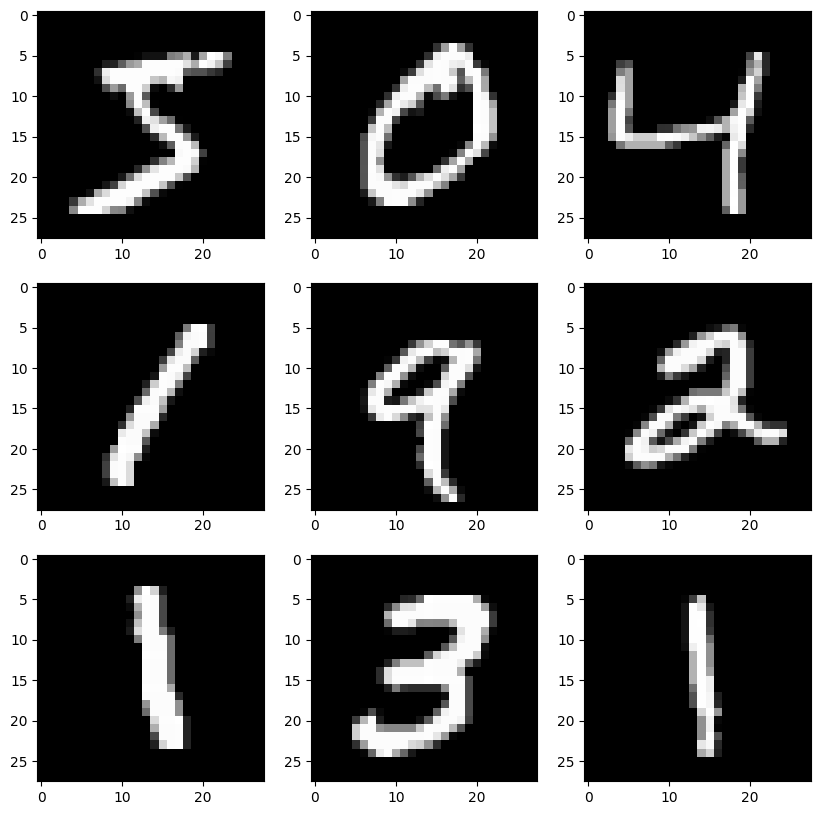

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
a = 0

for i in range(3):
    for j in range(3):
        axes[i, j].imshow(x_train_full[a], cmap=plt.get_cmap('gray'))
        a += 1
plt.show()

In [10]:
# This is when we do normilization happens
# We can see that our data ranges from (0-255) inidicating
# wether the pixel is black or white, 
# so we just scale that to the range [0, 1] instead of [0, 255]
# cuz that would be easier to deal with, when we calculate activation funcctions and gradients

In [9]:
x_valid, x_train = x_train_full[:5000] / 255, x_train_full[5000:] / 255
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
x_text = x_test / 255

In [10]:
x_train[1] # or x_valid[1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [11]:
y_valid, y_train

(array([5, 0, 4, ..., 2, 1, 2], shape=(5000,), dtype=uint8),
 array([7, 3, 4, ..., 5, 6, 8], shape=(55000,), dtype=uint8))

In [11]:
# Next: Define the class names

In [27]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [12]:
 y_train[100] # looking at the value of the first y train/ or do class_names[y_train[0]

np.uint8(7)

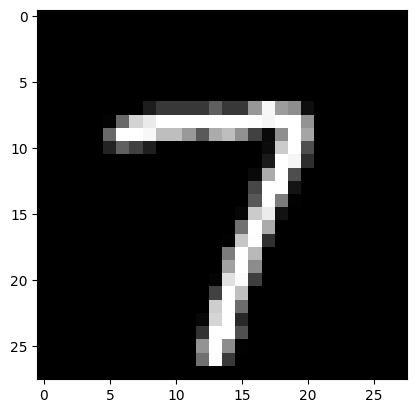

In [13]:
plt.imshow(x_train[100], cmap=plt.get_cmap('gray'))

In [ ]:
## Train the model

In [15]:
model = keras.models.Sequential() # building a model from keras
# adding them layers
model.add(keras.layers.Flatten(input_shape = [28, 28])) # flatten up the input

# the hidden layers
model.add(keras.layers.Dense(300, activation = 'relu')) # 1st hidden layer
model.add(keras.layers.Dense(100, activation = 'relu')) # 2nd hidden layer
model.add(keras.layers.Dense(10, activation = 'softmax')) # output layer with 10 label (neurons)



In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [29]:
# compile the model, choose loss function ,optimizer and metrics
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# fit the model around our data

In [30]:
# batch = The batch size is a hyperparameter that defines the number of samples to work through before updating the internal model parameters.
# epochs = how many times to do a pass over all the dataset

history = model.fit(x_train, y_train, epochs = 30, validation_data = (x_valid, y_valid), batch_size = 32) # also possible to use validation_split=0.1

Epoch 1/30


W0000 00:00:1775294701.553411    4464 cpu_allocator_impl.cc:82] Allocation of 172480000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9665 - loss: 0.1055 - val_accuracy: 0.9718 - val_loss: 0.0900
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9774 - loss: 0.0708 - val_accuracy: 0.9680 - val_loss: 0.1021
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9835 - loss: 0.0507 - val_accuracy: 0.9788 - val_loss: 0.0836
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9865 - loss: 0.0415 - val_accuracy: 0.9742 - val_loss: 0.1007
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9882 - loss: 0.0364 - val_accuracy: 0.9810 - val_loss: 0.0758
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9903 - loss: 0.0292 - val_accuracy: 0.9784 - val_loss: 0.0880
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9921 - loss: 0.0259 - val_accuracy: 0.9760 - val_loss: 0.0906
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9933 - loss: 0.0204 - val

In [26]:
# overfitting: taining loss getting lower and lower -> vl loss getting higher and hight
# we obviously do not wanna that

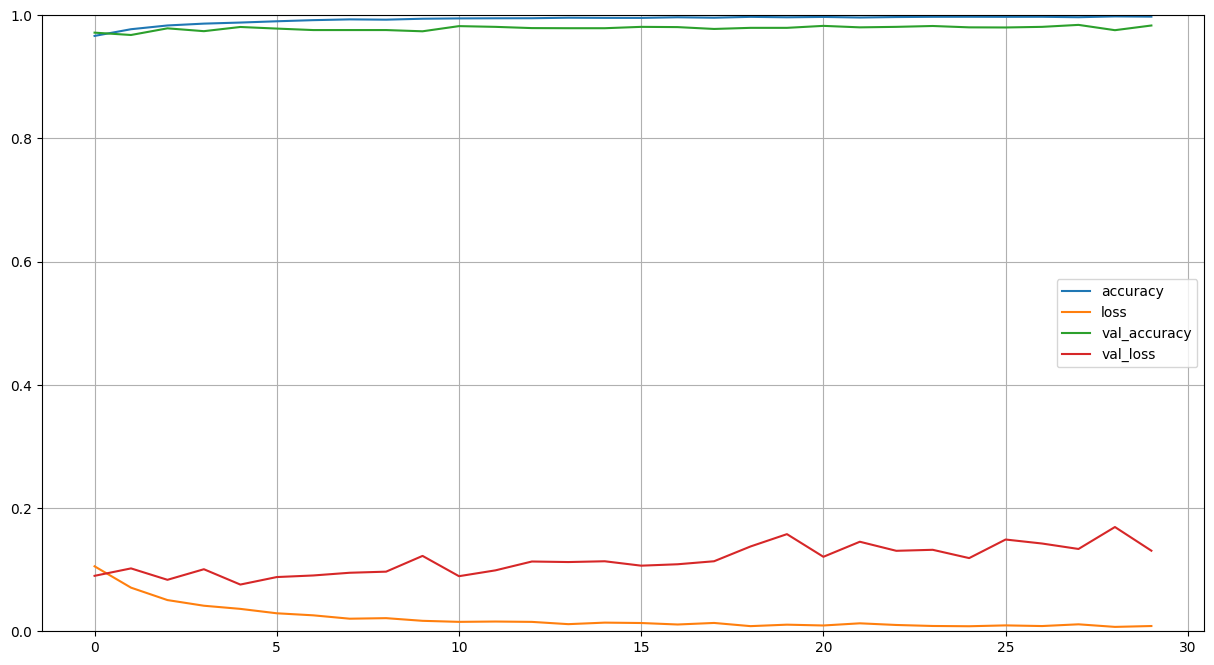

In [31]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [32]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9782 - loss: 43.3702


[43.3702392578125, 0.9782000184059143]

In [33]:
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.        , 0.        , 0.        , ..., 0.99999994, 0.        ,
        0.        ],
       [0.        , 0.        , 0.99999994, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(10000, 10), dtype=float32)

In [35]:
y_prob = model.predict(x_test)
y_classes = y_prob.argmax(axis=-1)
y_classes  # neatr, probability kinda thing

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [36]:
confusion_matrix = tf.math.confusion_matrix(y_test, y_classes)

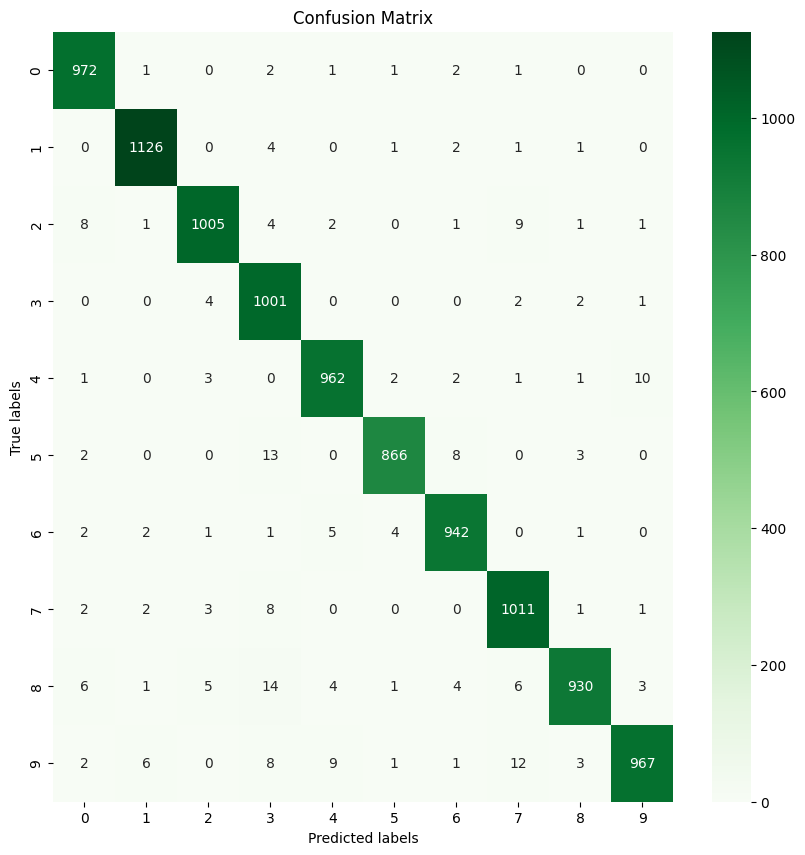

In [37]:
import seaborn as sb    

# ax = plt.figure(figsize=(8, 6))
fig = sb.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Greens')  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
fig.xaxis.set_ticklabels(class_names) 
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)


plt.show()

## solving overfitting

In [40]:
# 1. Remove softmax from the output layer
model.add(keras.layers.Dense(10))  # no activation

In [41]:
# 2. Use from_logits=True in the loss
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

In [43]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dropout(0.3),          # randomly kills 30% of neurons each step
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10)              # no softmax — logits only
])

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)